# 🧪 CartPole Balancing with Policy Gradient – Lab Tutorial

## 🎯 Objective

Train a neural network policy using Policy Gradient (REINFORCE) to balance a pole on a cart in the `CartPole-v1` environment using `gymnasium` and `PyTorch`.


## 👨‍🏫 What You'll Learn
- How to build a **neural policy** using PyTorch
- Use **REINFORCE** algorithm to improve the policy
- Visualize the training process
- Render the trained agent balancing the CartPole

👉 This notebook is interactive — run it cell-by-cell and follow the instructions!

In [1]:
# 🧰 Install Required Libraries
!pip install gymnasium torch numpy matplotlib --quiet

In [2]:
# 📦 Import Libraries
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 🏋️‍♂️ Define the Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.softmax(x, dim=-1)

In [4]:
# 🎮 Set Up the Environment and Policy
env = gym.make("CartPole-v1", render_mode=None)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy = PolicyNetwork(state_dim, action_dim)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

In [5]:
# 🔁 Define Policy Gradient Helper Functions
def select_action(state):
    state = torch.tensor(state, dtype=torch.float32)
    probs = policy(state)
    dist = torch.distributions.Categorical(probs)
    action = dist.sample()
    return action.item(), dist.log_prob(action)

def compute_returns(rewards, gamma=0.99):
    R = 0
    returns = []
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    returns = torch.tensor(returns)
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    return returns

In [6]:
# 🚂 Training Loop (REINFORCE)
num_episodes = 1000
all_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset()
    log_probs = []
    rewards = []
    done = False

    while not done:
        action, log_prob = select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state

    returns = compute_returns(rewards)

    loss = []
    for log_prob, R in zip(log_probs, returns):
        loss.append(-log_prob * R)
    loss = torch.stack(loss).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_reward = sum(rewards)
    all_rewards.append(total_reward)

    if episode % 50 == 0:
        print(f"Episode {episode}, Total Reward: {total_reward}")

Episode 0, Total Reward: 20.0
Episode 50, Total Reward: 90.0
Episode 100, Total Reward: 500.0
Episode 150, Total Reward: 500.0
Episode 200, Total Reward: 500.0
Episode 250, Total Reward: 290.0
Episode 300, Total Reward: 500.0
Episode 350, Total Reward: 11.0
Episode 400, Total Reward: 10.0
Episode 450, Total Reward: 10.0
Episode 500, Total Reward: 10.0
Episode 550, Total Reward: 10.0
Episode 600, Total Reward: 10.0
Episode 650, Total Reward: 9.0
Episode 700, Total Reward: 8.0
Episode 750, Total Reward: 8.0
Episode 800, Total Reward: 9.0
Episode 850, Total Reward: 9.0
Episode 900, Total Reward: 9.0
Episode 950, Total Reward: 9.0


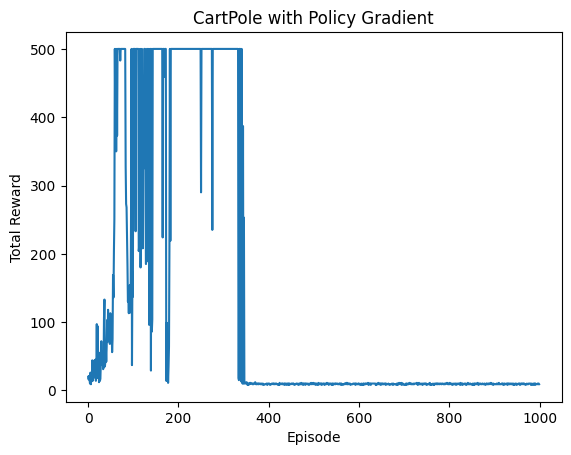

In [7]:
# 📈 Plot the Rewards
plt.plot(all_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('CartPole with Policy Gradient')
plt.show()

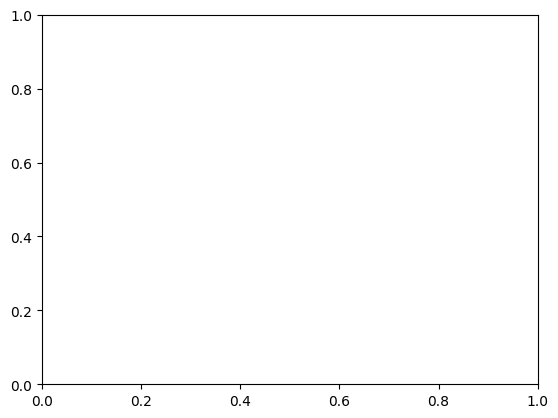

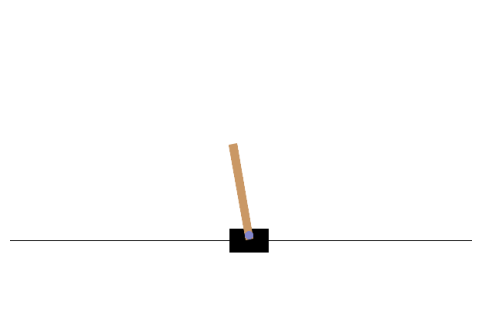

: 

In [ ]:
# 🧪 Visual Test with Matplotlib Animation
from matplotlib import animation, pyplot as plt
from IPython.display import HTML

frames = []
state, _ = env.reset()
done = False
total_reward = 0

fig, ax = plt.subplots()
env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()

while not done:
    frame = env.render()
    frames.append(frame)
    action, _ = select_action(state)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward

env.close()

# Create animation
def display_animation(frames):
    fig = plt.figure(figsize=(6,4))
    patch = plt.imshow(frames[0])
    plt.axis('off')
    
    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=30)
    return HTML(anim.to_jshtml())

display_animation(frames)